In [ ]:
########## 1
# Imports: core libraries needed for this notebook
#
# Purpose:
# This notebook performs exploratory data analysis on an IMDb-derived
# analytical dataset stored in a local SQLite database.
#
# Design choice:
# Only standard, commonly available libraries are used:
# sqlite3 for database access, pandas for tabular analysis,
# numpy for numeric transforms, matplotlib for plotting.
##########

# SQLite database connectivity and SQL execution
import sqlite3

# DataFrame operations: filtering, grouping, summarizing, and tabular inspection
import pandas as pd

# Numeric utilities: logarithmic transforms, handling numeric arrays
import numpy as np

# Plotting library for EDA visuals (histograms, scatter plots, box plots)
import matplotlib.pyplot as plt

In [ ]:
########## 2
# Database connection
#
# Purpose:
# Connect to the local SQLite database that contains the IMDb dataset.
# The database is stored locally to ensure reproducibility and eliminate
# external dependencies during analysis.
#
# Output:
# - Active SQLite connection object (conn)
# - Confirmation of SQLite engine version
##########

# Relative path to the SQLite database file inside the repository
db_path = "../imdb_data.db"

# Create connection to SQLite database
conn = sqlite3.connect(db_path)

# Confirm successful connection by retrieving SQLite engine version
cursor = conn.cursor()
cursor.execute("SELECT sqlite_version();")
sqlite_version = cursor.fetchone()[0]
cursor.close()

print("Connected to SQLite version:", sqlite_version)

Connected to SQLite version: 3.40.1


In [ ]:
########## 3
# Load analytical dataset
#
# Purpose:
# Pull the pre-defined SQL view "analysis_movies" into a pandas DataFrame.
#
# Why a SQL view:
# The view standardizes scope and filters in one place, so analysis steps
# remain consistent across reruns and future revisions.
#
# Expected columns (based on the view):
# - tconst, primaryTitle, startYear, runtimeMinutes, genres
# - averageRating, numVotes
##########

query = """
SELECT *
FROM analysis_movies;
"""

# Execute query and load results into a DataFrame
df = pd.read_sql_query(query, conn)

# Confirm dimensions for reproducibility and sanity checking
print("Dataset shape (rows, columns):", df.shape)

# Preview rows to confirm the dataset loaded correctly
df.head(10)

Dataset shape (rows, columns): (331394, 7)


,tconst,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,Miss Jerry,1894.0,45,Romance,5.2,231
1,tt0000147,The Corbett-Fitzsimmons Fight,1897.0,100,"Documentary,News,Sport",5.3,578
2,tt0000335,Soldiers of the Cross,1900.0,40,"Biography,Drama",5.5,64
3,tt0000502,Bohemios,1905.0,100,None,3.1,25
4,tt0000574,The Story of the Kelly Gang,1906.0,70,"Action,Adventure,Biography",6.0,1039
5,tt0000591,The Prodigal Son,1907.0,90,Drama,4.8,36
6,tt0000615,Robbery Under Arms,1907.0,None,Drama,3.6,32
7,tt0000630,Hamlet,1908.0,None,Drama,3.0,36
8,tt0000675,Don Quijote,1908.0,None,Drama,4.0,26
9,tt0000679,The Fairylogue and Radio-Plays,1908.0,120,"Adventure,Fantasy",5.1,81


In [6]:
########## 4
# Structural inspection
#
# Purpose:
# Confirm column types, missingness patterns, and numerical ranges.
# This is the first checkpoint before any grouping or modeling.
#
# Outputs:
# - df.info(): column names, data types, non-null counts
# - df.describe(): numeric summary statistics for numeric columns
##########

df.info()

# Descriptive statistics for numeric columns
# Note: pandas describes only numeric columns by default
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331394 entries, 0 to 331393
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          331394 non-null  object 
 1   primaryTitle    331393 non-null  object 
 2   startYear       331361 non-null  float64
 3   runtimeMinutes  298981 non-null  object 
 4   genres          320557 non-null  object 
 5   averageRating   331394 non-null  float64
 6   numVotes        331394 non-null  int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 17.7+ MB


,startYear,averageRating,numVotes
count,331361.000000,331394.000000,3.313940e+05
mean,1997.402872,6.186075,3.737174e+03
std,26.199632,1.384322,3.770491e+04
min,1894.000000,1.000000,5.000000e+00
25%,1982.000000,5.400000,2.000000e+01
50%,2008.000000,6.300000,6.500000e+01
75%,2017.000000,7.100000,3.340000e+02
max,2025.000000,10.000000,3.128623e+06


In [7]:
########## 5
# Missing value assessment
#
# Purpose:
# Identify missing values by column.
# Missingness affects grouping (genre comparisons), transformations,
# and downstream modeling choices.
##########

missing_counts = df.isna().sum().sort_values(ascending=False)

print("Missing values by column (descending):")
print(missing_counts)

Missing values by column (descending):
runtimeMinutes    32413
genres            10837
startYear            33
primaryTitle          1
tconst                0
averageRating         0
numVotes              0
dtype: int64


In [8]:
########## 6
# Feature preparation: engagement variable
#
# Purpose:
# Define an engagement measure for analysis and visualization.
#
# Design choice:
# "numVotes" is used as the primary engagement proxy because it reflects
# participation volume. Vote counts are typically heavily right-skewed,
# so a log transform is created to support comparisons and modeling.
#
# Implementation:
# log_votes = log( numVotes + 1 )
# log1p() is used to handle numVotes = 0 safely.
##########

# Ensure vote counts are numeric
# This protects against unexpected types if data was imported as text
df["numVotes"] = pd.to_numeric(df["numVotes"], errors="coerce")

# Log-transform vote counts for stability and interpretability
df["log_votes"] = np.log1p(df["numVotes"])

# Quick verification of the new field
df[["numVotes", "log_votes"]].head(10)

,numVotes,log_votes
0,231,5.446737
1,578,6.361302
2,64,4.174387
3,25,3.258097
4,1039,6.946976
5,36,3.610918
6,32,3.496508
7,36,3.610918
8,26,3.295837
9,81,4.406719


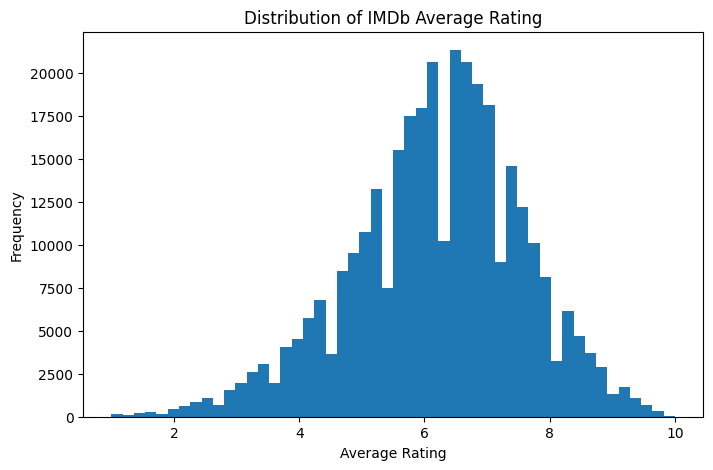

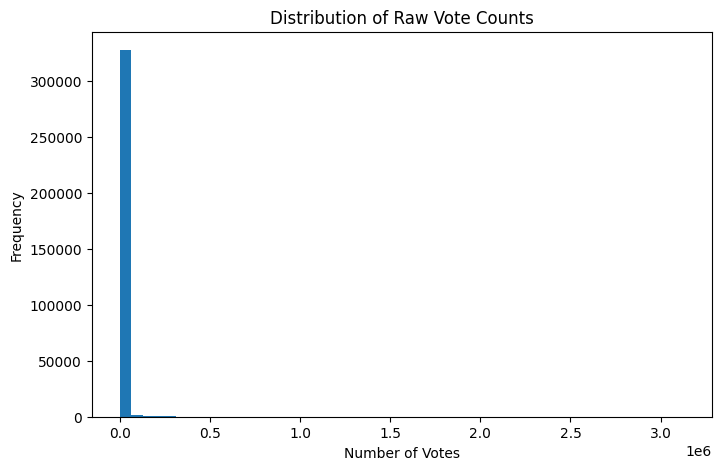

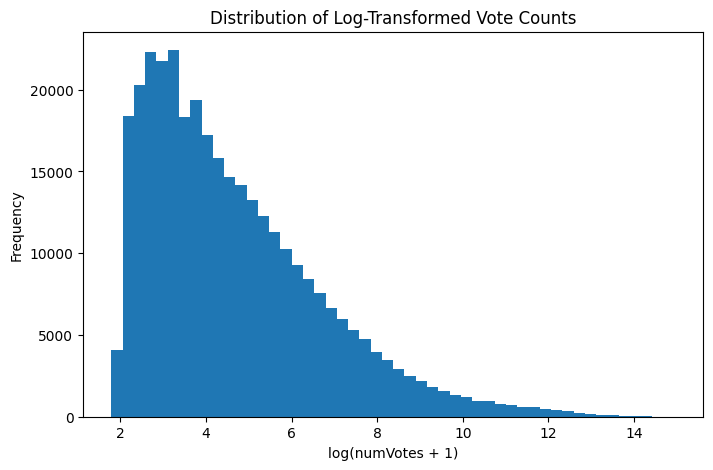

In [9]:
########## 7
# Distribution checks: rating and engagement
#
# Purpose:
# Visualize key variable distributions to understand:
# - range and central tendency
# - skew and outliers
# - whether transforms are needed for meaningful comparisons
#
# Plots produced:
# - Histogram of averageRating
# - Histogram of raw numVotes
# - Histogram of log_votes
##########

# Histogram: averageRating
plt.figure(figsize=(8, 5))
plt.hist(df["averageRating"].dropna(), bins=50)
plt.title("Distribution of IMDb Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()

# Histogram: raw numVotes
plt.figure(figsize=(8, 5))
plt.hist(df["numVotes"].dropna(), bins=50)
plt.title("Distribution of Raw Vote Counts")
plt.xlabel("Number of Votes")
plt.ylabel("Frequency")
plt.show()

# Histogram: log-transformed vote counts
plt.figure(figsize=(8, 5))
plt.hist(df["log_votes"].dropna(), bins=50)
plt.title("Distribution of Log-Transformed Vote Counts")
plt.xlabel("log(numVotes + 1)")
plt.ylabel("Frequency")
plt.show()

In [10]:
########## 8
# Remove rows with missing genre information
#
# Rationale:
# Genre is a primary production attribute in this analysis.
# Rows without genre cannot be categorized meaningfully.
##########

df = df[df["genres"].notna()].copy()

print("Shape after removing missing genres:", df.shape)

Shape after removing missing genres: (320557, 8)


In [11]:
########## 9
# Inspect genre ordering structure
#
# Purpose:
# Determine whether genres appear alphabetically within each record.
# This verifies whether the first genre represents a primary category
# or simply alphabetical ordering.
##########

# Take a sample of rows with multiple genres
sample_multi = df[df["genres"].str.contains(",")].sample(20, random_state=42)

# Split genres into lists
sample_multi["genre_list"] = sample_multi["genres"].str.split(",")

# Check alphabetical ordering
sample_multi["is_alphabetical"] = sample_multi["genre_list"].apply(
    lambda x: x == sorted(x)
)

sample_multi[["genres", "genre_list", "is_alphabetical"]]

,genres,genre_list,is_alphabetical
270571,"Comedy,Sport","[Comedy, Sport]",True
162195,"Drama,Western","[Drama, Western]",True
149932,"Comedy,Drama,Romance","[Comedy, Drama, Romance]",True
308023,"Action,Biography,Drama","[Action, Biography, Drama]",True
204582,"Documentary,History","[Documentary, History]",True
171006,"Action,Drama","[Action, Drama]",True
190352,"Animation,Music","[Animation, Music]",True
129,"Drama,History","[Drama, History]",True
274080,"Drama,Horror,Mystery","[Drama, Horror, Mystery]",True
288874,"Action,Crime,Mystery","[Action, Crime, Mystery]",True


In [12]:
########## 10
# One-hot encode multi-label genres
#
# Purpose:
# Convert comma-separated genre strings into binary indicator columns.
# Each genre becomes a 0/1 feature for modeling.
#
# Notes:
# - Assumes missing genres have already been removed.
# - Safe to rerun without duplicating columns.
##########

# Remove existing genre_ columns if cell is rerun
df = df.loc[:, ~df.columns.str.startswith("genre_")]

# Split genres into lists
df["genre_list"] = df["genres"].str.split(",")

# Explode for encoding
genre_exploded = df.explode("genre_list")

# One-hot encode and ensure integer type
genre_dummies = pd.get_dummies(
    genre_exploded["genre_list"],
    prefix="genre",
    dtype=int
)

# Recombine to original index
genre_matrix = genre_dummies.groupby(genre_exploded.index).max()

# Merge back into main dataframe
df = df.join(genre_matrix)

print("New shape after genre encoding:", df.shape)

New shape after genre encoding: (320557, 36)


In [ ]:
########## 11a
# Genre frequency distribution
#
# Purpose:
# Determine how often each genre appears after cleaning.
# This helps identify rare categories that may destabilize regression.
##########

genre_counts = (
    df["genres"]
    .str.split(",")
    .explode()
    .value_counts()
    .sort_values(ascending=False)
)

genre_counts.head(20)

genres
Drama          151896
Comedy          79988
Documentary     54688
Romance         36339
Action          34346
Crime           28902
Thriller        28412
Horror          25769
Adventure       20296
Mystery         13270
Family          12848
Biography       10618
Fantasy         10113
History          9470
Music            8523
Sci-Fi           7905
Musical          6975
War              6695
Animation        6042
Western          5034
Name: count, dtype: int64

In [14]:
########## 11b
# Genre frequency distribution
#
# Purpose:
# Determine how often each genre appears after cleaning.
# This helps identify rare categories that may destabilize regression.
##########

genre_counts = (
    df["genres"]
    .str.split(",")
    .explode()
    .value_counts()
    .sort_values(ascending=False)
)

genre_counts.head(10)

genres
Drama          151896
Comedy          79988
Documentary     54688
Romance         36339
Action          34346
Crime           28902
Thriller        28412
Horror          25769
Adventure       20296
Mystery         13270
Name: count, dtype: int64